In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

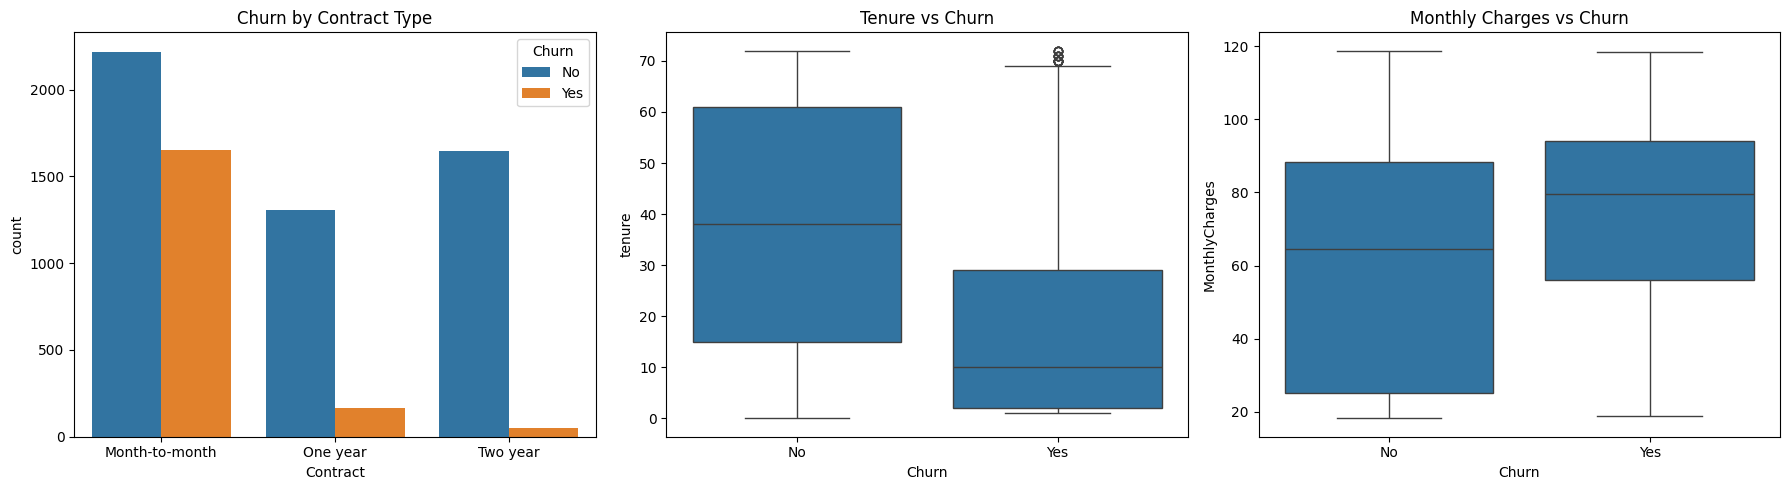

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0])
axes[0].set_title('Churn by Contract Type')

sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[1])
axes[1].set_title('Tenure vs Churn')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[2])
axes[2].set_title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

### EDA Observations

- **Contract type** clearly matters — customers on month-to-month contracts churn far more than those on one or two year contracts.
- **Tenure** — customers who churn tend to have much lower tenure, meaning newer customers are more likely to leave.
- **Monthly Charges** — customers who churn tend to have higher monthly charges on average, suggesting price sensitivity plays a role.

In [13]:
df_encoded = df.drop(columns=['customerID'])
df_encoded['Churn'] = df_encoded['Churn'].map({'No': 0, 'Yes': 1})

categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

df_encoded.head()

C:\Users\X280\AppData\Local\Temp\ipykernel_2620\1516564600.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [14]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))

Decision Tree Accuracy: 0.794180269694819
Logistic Regression Accuracy: 0.8048261178140526


c:\Users\X280\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
print("Decision Tree Report:\n", classification_report(y_test, tree_pred))
print("\nLogistic Regression Report:\n", classification_report(y_test, log_pred))

Decision Tree Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409


Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [17]:
importances = pd.Series(tree_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(3)
top_features

tenure                         0.421435
InternetService_Fiber optic    0.357542
TotalCharges                   0.047129
dtype: float64

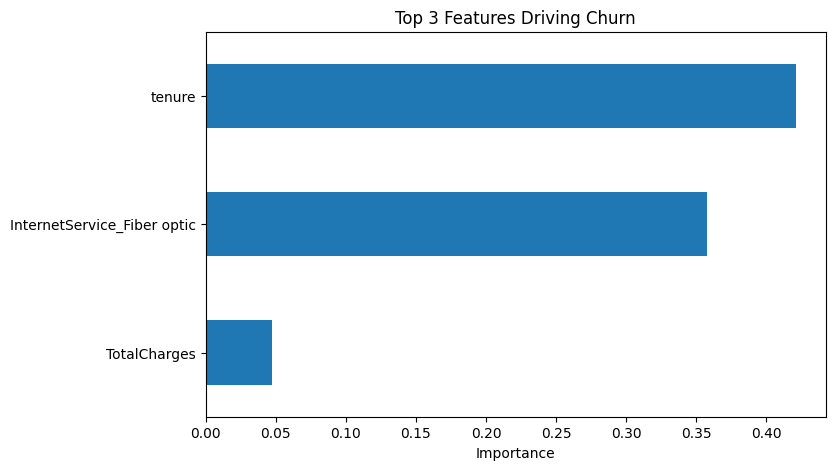

In [18]:
plt.figure(figsize=(8,5))
top_features.plot(kind='barh')
plt.title('Top 3 Features Driving Churn')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

### Business Summary

Our analysis shows that about 27% of customers are churning, which is a significant retention problem worth addressing. The biggest driver of churn is **customer tenure** — newer customers are far more likely to leave than long-term ones, suggesting the first few months are critical for building loyalty. Customers using **Fiber Optic internet** also churn more, possibly due to pricing or service quality concerns with that plan. We recommend focusing retention efforts on new customers and reviewing the Fiber Optic offering, as these two factors alone explain most of the churn behavior our model detected.